# Computer Vision Mini Project
#### - Name: Jasser Abdelfattah
#### - UH ID: 21033101

## Loading CIFAR-10 and Data Preprocessing


In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import numpy as np
import cv2

In [2]:
# Number of epochs to train the model
num_epochs = 10

# Batch size for training
batch_size = 128

# Learning rate for the optimizer
learning_rate = 0.009739054477909789

In [3]:
def histogram_equalization(image):
    """
    Apply histogram equalization to the input image to improve its contrast.

    Parameters:
    image (numpy.ndarray): Input image in RGB format.

    Returns:
    numpy.ndarray: Image with equalized histogram in RGB format.
    """
    img_y_cr_cb = cv2.cvtColor(image, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(img_y_cr_cb)
    y_eq = cv2.equalizeHist(y)
    img_y_cr_cb_eq = cv2.merge((y_eq, cr, cb))
    img_rgb_eq = cv2.cvtColor(img_y_cr_cb_eq, cv2.COLOR_YCrCb2RGB)
    return img_rgb_eq

In [4]:
class CIFAR10WithHE(CIFAR10):
    """
    CIFAR10WithHE is a subclass of the CIFAR10 dataset that applies histogram equalization to each image.

    Methods
    -------
    __getitem__(index)
        Retrieves the image and target at the specified index, applies histogram equalization to the image,
        and then applies any additional transformations if specified.

    Parameters
    ----------
    index : int
        The index of the image and target to retrieve.

    Returns
    -------
    tuple
        A tuple containing the transformed image and its corresponding target.
    """

    def __getitem__(self, index):
        img, target = self.data[index], self.targets[index]
        img = Image.fromarray(img)
        img = np.array(img)
        img = histogram_equalization(img)
        img = Image.fromarray(img)
        if self.transform is not None:
            img = self.transform(img)
        return img, target

# Define a transform to normalize the data
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

# Load the training dataset with histogram equalization
train_dataset = CIFAR10WithHE(
    root="./CIFAR10_data", train=True, download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)

# Load the test dataset with histogram equalization
test_dataset = CIFAR10WithHE(
    root="./CIFAR10_data", train=False, download=True, transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True, num_workers=2
)

# Define the classes in the CIFAR-10 dataset
classes = (
    "plane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
    )

100%|██████████| 170M/170M [00:03<00:00, 45.3MB/s]


Extracting ./CIFAR10_data/cifar-10-python.tar.gz to ./CIFAR10_data
Files already downloaded and verified


## Building The Object Recognition Model Using Convolutional Neural Network Architecture


In [5]:
import torch.nn as nn
import torch.nn.functional as F

In [6]:
# Define a Convolutional Neural Network (CNN) class
class CCN(nn.Module):
    def __init__(self):
        super(CCN, self).__init__()
        # First convolutional layer: 3 input channels (RGB), 16 output channels, 3x3 kernel, stride 1, padding 1
        self.conv1 = nn.Conv2d(3, 16, 3, 1, padding=1)
        # Second convolutional layer: 16 input channels, 32 output channels, 3x3 kernel, stride 1, padding 1
        self.conv2 = nn.Conv2d(16, 32, 3, 1, padding=1)
        # Third convolutional layer: 32 input channels, 64 output channels, 3x3 kernel, stride 1, padding 1
        self.conv3 = nn.Conv2d(32, 64, 3, 1, padding=1)
        # Fully connected layer: input size 4*4*64, output size 500
        self.fc1 = nn.Linear(4 * 4 * 64, 500)
        # Dropout layer with a dropout probability of 0.2
        self.dropout = nn.Dropout(0.2)
        # Fully connected layer: input size 500, output size 10 (number of classes)
        self.fc2 = nn.Linear(500, 10)

    def forward(self, x):
        # Apply first convolutional layer followed by ReLU activation and max pooling
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)
        # Apply second convolutional layer followed by ReLU activation and max pooling
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)
        # Apply third convolutional layer followed by ReLU activation and max pooling
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2, 2)
        # Flatten the tensor for the fully connected layer
        x = x.view(-1, 4 * 4 * 64)
        # Apply first fully connected layer followed by ReLU activation
        x = F.relu(self.fc1(x))
        # Apply dropout
        x = self.dropout(x)
        # Apply second fully connected layer
        x = self.fc2(x)
        return x

# Check if GPU is available and set the device accordingly
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Instantiate the model and move it to the appropriate device
model = CCN().to(device)
model

CCN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1024, out_features=500, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)

## Training the CNN (Convolutional Neural Network) Model


In [7]:
import torch.optim as optim

In [8]:
# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

In [9]:
running_loss_history = []
running_corrects_history = []
test_running_loss_history = []
test_running_corrects_history = []

# Loop over the number of epochs
for e in range(num_epochs):
    running_loss = 0.0
    running_corrects = 0.0
    test_running_loss = 0.0
    test_running_corrects = 0.0

    # Training phase
    for inputs, labels in train_loader:
        inputs = inputs.to(device)  # Move inputs to the device (GPU or CPU)
        labels = labels.to(device)  # Move labels to the device (GPU or CPU)
        outputs = model(inputs)  # Forward pass
        loss = criterion(outputs, labels)  # Compute the loss

        optimizer.zero_grad()  # Zero the gradients
        loss.backward()  # Backward pass
        optimizer.step()  # Update the weights

        _, preds = torch.max(outputs, 1)  # Get the predictions
        running_loss += loss.item()  # Accumulate the loss
        running_corrects += torch.sum(
            preds == labels.data
        )  # Accumulate the correct predictions

    # Testing phase
    else:
        with torch.no_grad():  # Disable gradient calculation
            for test_inputs, test_labels in test_loader:
                test_inputs = test_inputs.to(device)  # Move test inputs to the device
                test_labels = test_labels.to(device)  # Move test labels to the device
                test_outputs = model(test_inputs)  # Forward pass
                test_loss = criterion(
                    test_outputs, test_labels
                )  # Compute the test loss

                _, test_preds = torch.max(test_outputs, 1)  # Get the test predictions
                test_running_loss += test_loss.item()  # Accumulate the test loss
                test_running_corrects += torch.sum(
                    test_preds == test_labels.data
                )  # Accumulate the correct test predictions

        # Compute the average training loss and accuracy for the epoch
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = running_corrects.float() / len(train_loader)
        running_loss_history.append(epoch_loss)  # Store the training loss
        running_corrects_history.append(epoch_acc)  # Store the training accuracy

        # Compute the average testing loss and accuracy for the epoch
        test_epoch_loss = test_running_loss / len(test_loader)
        test_epoch_acc = test_running_corrects.float() / len(test_loader)
        test_running_loss_history.append(test_epoch_loss)  # Store the test loss
        test_running_corrects_history.append(test_epoch_acc)  # Store the test accuracy

        # Print the training and testing loss and accuracy for the epoch
        print(f"epoch: {e + 1}")
        print(f"training loss: {epoch_loss:.4f}, acc {epoch_acc:.4f}")
        print(f"testing loss: {test_epoch_loss:.4f}, acc {test_epoch_acc:.4f}")

epoch: 1
training loss: 1.9531, acc 35.8593
testing loss: 1.5763, acc 53.9494
epoch: 2
training loss: 1.4443, acc 61.0588
testing loss: 1.3196, acc 66.8354
epoch: 3
training loss: 1.2251, acc 72.0179
testing loss: 1.1808, acc 74.3671
epoch: 4
training loss: 1.0704, acc 79.2864
testing loss: 1.0794, acc 78.8354
epoch: 5
training loss: 0.9549, acc 84.6982
testing loss: 1.0011, acc 81.6962
epoch: 6
training loss: 0.8680, acc 88.8491
testing loss: 1.0016, acc 83.1772
epoch: 7
training loss: 0.7838, acc 92.7954
testing loss: 0.9876, acc 83.2405
epoch: 8
training loss: 0.7183, acc 95.5294
testing loss: 0.9072, acc 88.0760
epoch: 9
training loss: 0.6511, acc 98.3274
testing loss: 0.9126, acc 87.1139
epoch: 10
training loss: 0.5896, acc 101.3171
testing loss: 0.9367, acc 87.4304


In [10]:
PATH = "./custom_model_cifar10.pth"
torch.save(model.state_dict(), PATH)

## Evaluating the Object Recognition Model

In [11]:
net = CCN()
net.load_state_dict(torch.load(PATH))
net.to(device)

<ipython-input-11-4b1b1dfae6bb>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  net.load_state_dict(torch.load(PATH))


CCN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1024, out_features=500, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=500, out_features=10, bias=True)
)

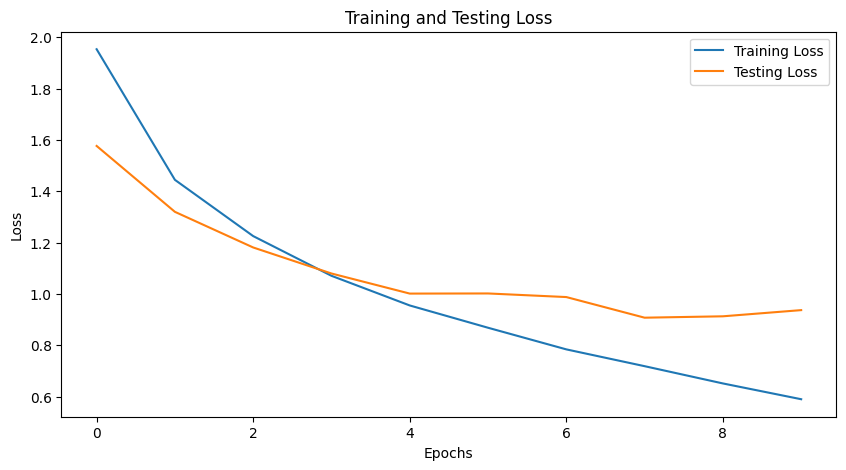

In [12]:
# Plot the training and testing loss
plt.figure(figsize=(10, 5))
plt.plot(running_loss_history, label="Training Loss")
plt.plot(test_running_loss_history, label="Testing Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Testing Loss")
plt.show()

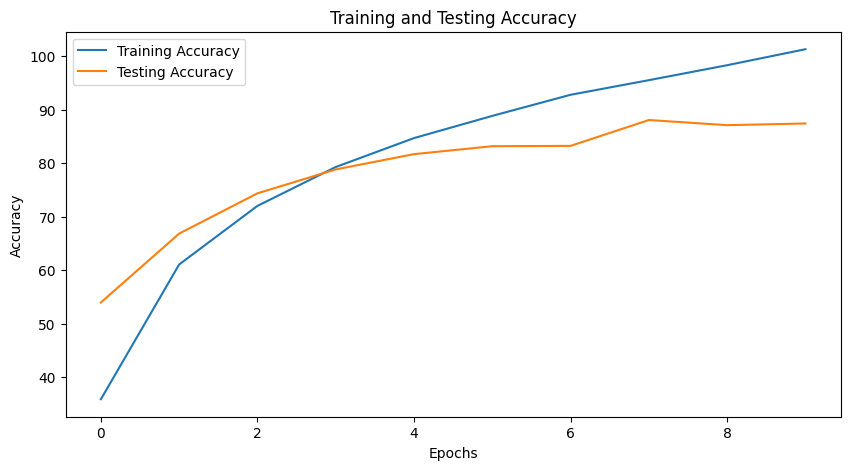

In [13]:
# Plot the training and testing accuracy
plt.figure(figsize=(10, 5))
plt.plot(
    [acc.cpu().numpy() for acc in running_corrects_history], label="Training Accuracy"
)
plt.plot(
    [acc.cpu().numpy() for acc in test_running_corrects_history],
    label="Testing Accuracy",
)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Testing Accuracy")
plt.show()

In [14]:
net.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = net(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [15]:
# Calculate and print classification report
print(classification_report(all_labels, all_preds, target_names=classes))

              precision    recall  f1-score   support

       plane       0.73      0.74      0.74      1000
  automobile       0.83      0.83      0.83      1000
        bird       0.57      0.63      0.60      1000
         cat       0.52      0.54      0.53      1000
        deer       0.57      0.76      0.65      1000
         dog       0.68      0.49      0.57      1000
        frog       0.77      0.76      0.77      1000
       horse       0.85      0.72      0.78      1000
        ship       0.75      0.83      0.79      1000
       truck       0.88      0.73      0.80      1000

    accuracy                           0.70     10000
   macro avg       0.72      0.70      0.71     10000
weighted avg       0.72      0.70      0.71     10000



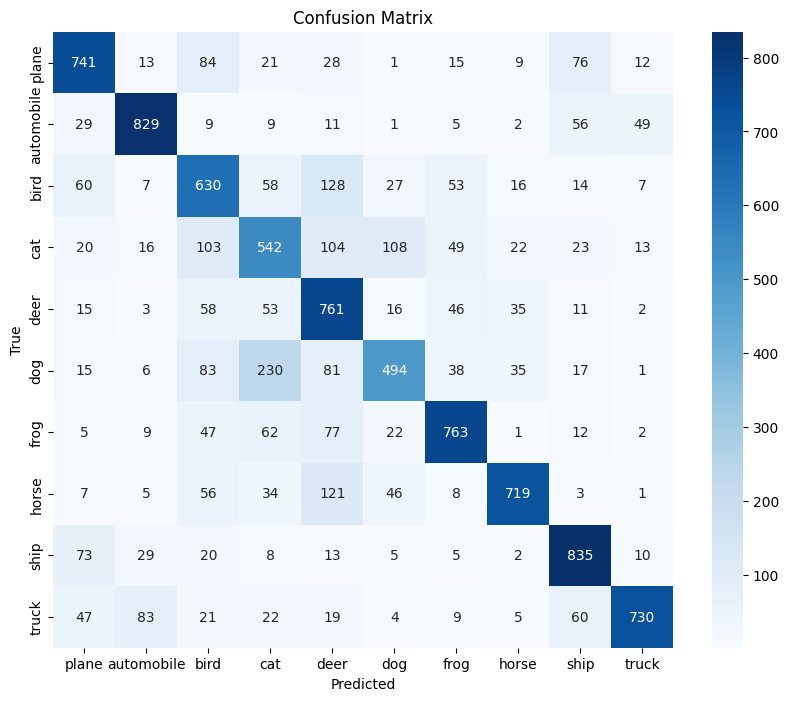

In [16]:
# Calculate and plot confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [18]:
# Disable gradient calculation for evaluation
with torch.no_grad():
    # Initialize class_correct and class_total to store correct predictions and total samples for each class
    class_correct = [0] * len(classes)  # Initialize with 0 for each class
    class_total = [0] * len(classes)  # Initialize with 0 for each class

    for data in test_loader:
        images, labels = data  # Get the images and labels from the test loader
        images = images.to(device) # Move images to the same device as the model
        labels = labels.to(device) # Move labels to the same device as the model
        outputs = net(images)  # Forward pass: compute the outputs of the network
        _, predicted = torch.max(
            outputs, 1
        )  # Get the predicted class with the highest score
        c = (predicted == labels).squeeze()  # Compare predictions with the true labels

        # Update the correct predictions and total samples for each class
        for i in range(len(labels)):
            label = labels[i]  # Get the true label
            class_correct[label] += c[
                i
            ].item()  # Increment the correct count for the class
            class_total[label] += 1  # Increment the total count for the class

    # Print the accuracy for each class
    for i in range(len(classes)):
        if class_total[i] > 0:
            print(
                "Accuracy of %5s : %2d %%"
                % (classes[i], 100 * class_correct[i] / class_total[i])
            )

    # Calculate and print the overall accuracy of the network
    overall_accuracy = 100.0 * sum(class_correct) / sum(class_total)
    print("Accuracy of the network on the 10000 test images: %d %%" % overall_accuracy)

Accuracy of plane : 74 %
Accuracy of automobile : 82 %
Accuracy of  bird : 63 %
Accuracy of   cat : 54 %
Accuracy of  deer : 76 %
Accuracy of   dog : 49 %
Accuracy of  frog : 76 %
Accuracy of horse : 71 %
Accuracy of  ship : 83 %
Accuracy of truck : 73 %
Accuracy of the network on the 10000 test images: 70 %


## Prediction on Unseen Images


In [20]:
import os

In [21]:
# Example usage
folder_path = "UnseenImages"

In [22]:
def display_images_in_folder(folder_path):
    # Iterate through all images in the folder
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        image = Image.open(image_path)

        # Display the image
        plt.imshow(image)
        plt.title(f"File: {image_name}")
        plt.axis('off')  # Hide the axis
        plt.show()

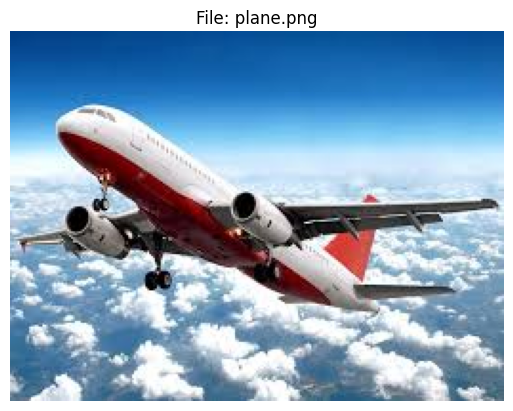

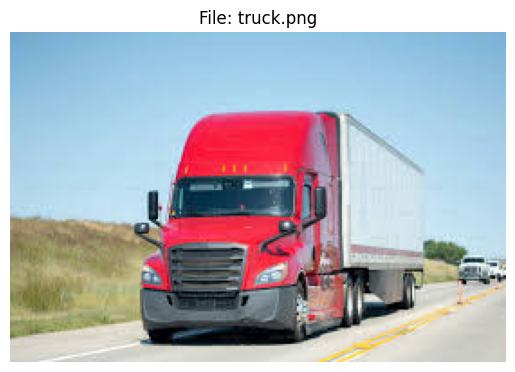

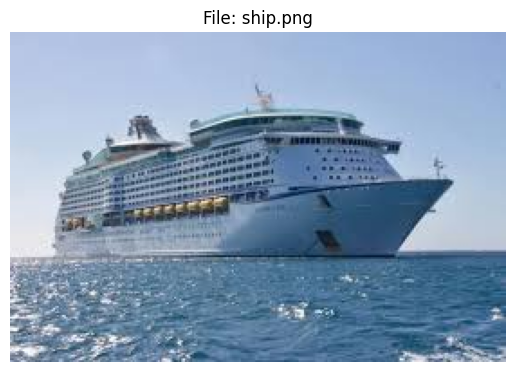

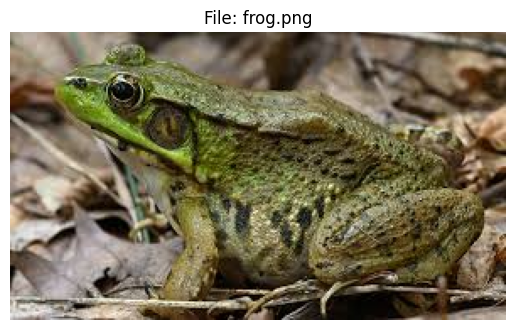

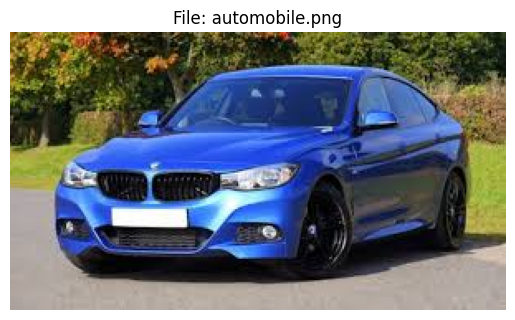

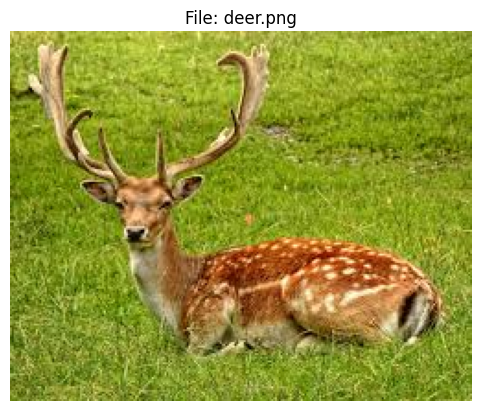

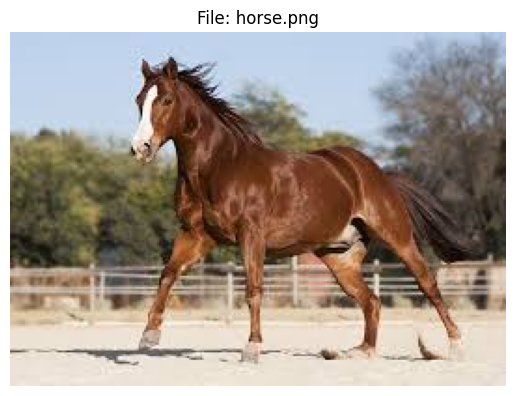

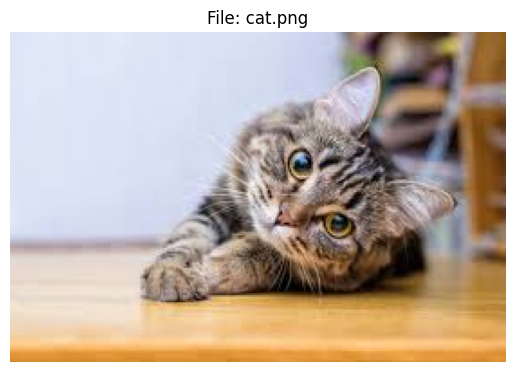

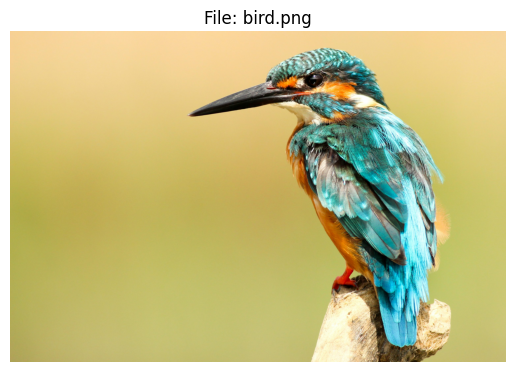

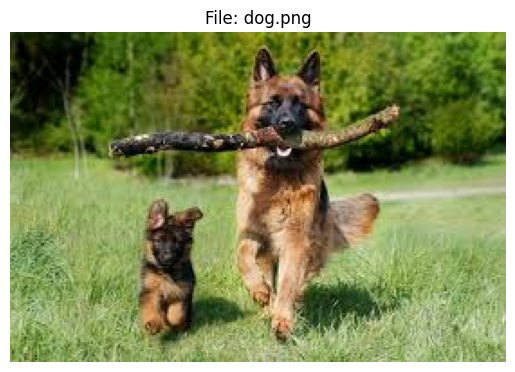

In [23]:
display_images_in_folder(folder_path)

In [24]:
def predict_images_in_folder(model, folder_path, classes, device):
    # Define the image transformations (resize, normalize, etc.)
    transform = transforms.Compose([
        transforms.Resize((32, 32)),  # Resize the image to the input size expected by the model
        transforms.ToTensor(),  # Convert the image to a tensor
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize the image
    ])

    # Set the model to evaluation mode
    model.eval()

    # Iterate through all images in the folder
    for image_name in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image_name)
        image = Image.open(image_path)
        image = transform(image).unsqueeze(0)  # Apply transformations and add batch dimension
        image = image.to(device)  # Move the image to the device (GPU or CPU)

        # Disable gradient calculation
        with torch.no_grad():
            outputs = net(image)  # Forward pass: compute the outputs of the network
            _, predicted = torch.max(outputs, 1)  # Get the predicted class with the highest score

        predicted_class = classes[predicted.item()]  # Get the predicted class label

        # Display the image along with the predicted label and file name
        image = image.cpu().squeeze().permute(1, 2, 0).numpy()  # Move image back to CPU and convert to numpy array
        image = image * 0.5 + 0.5  # Unnormalize the image
        plt.imshow(image)
        plt.title(f"Predicted: {predicted_class}\nImage Label: {image_name}")
        plt.show()

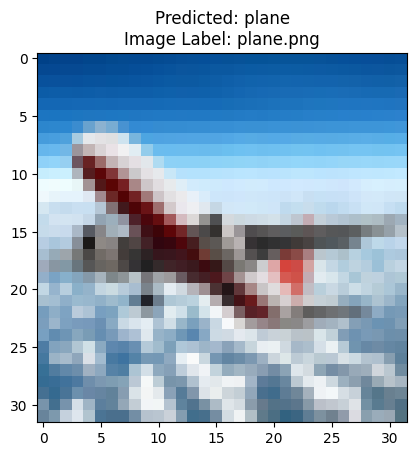

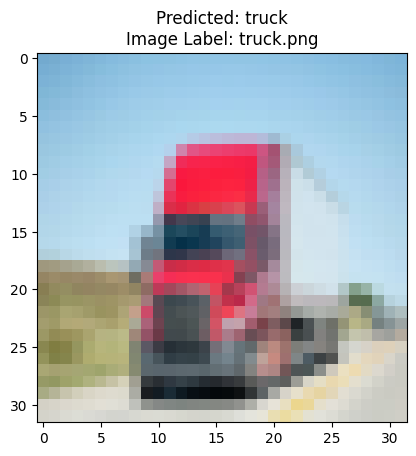

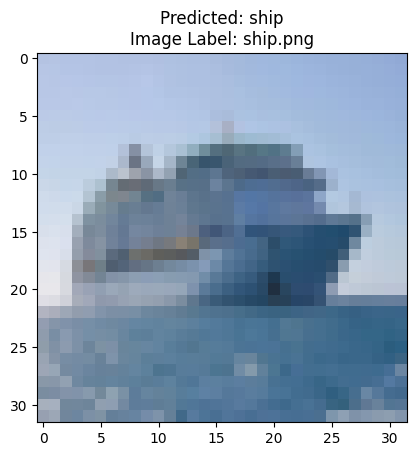

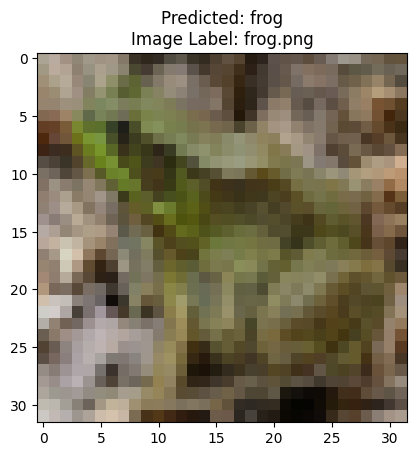

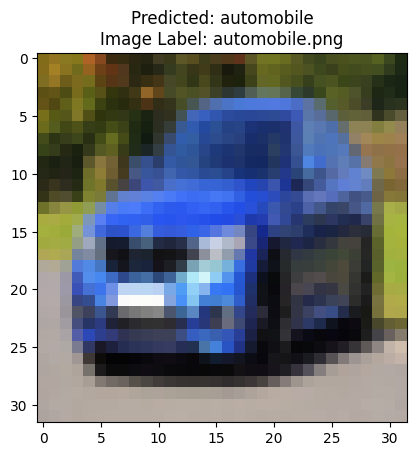

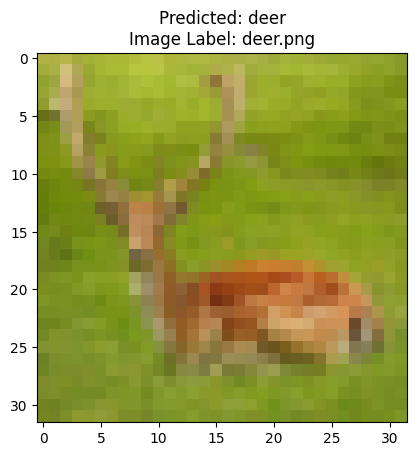

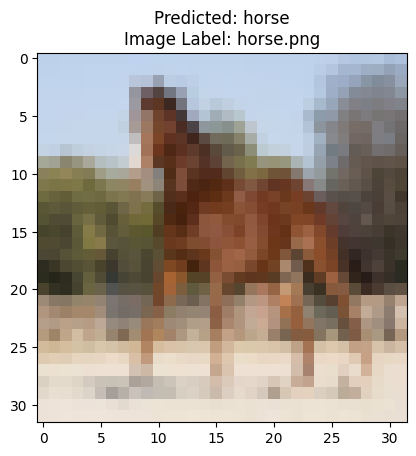

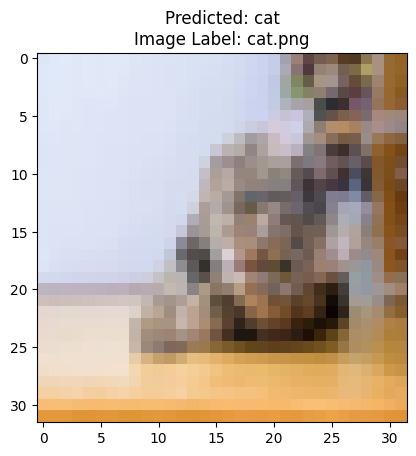

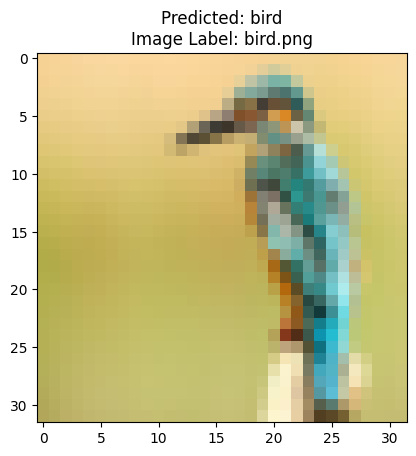

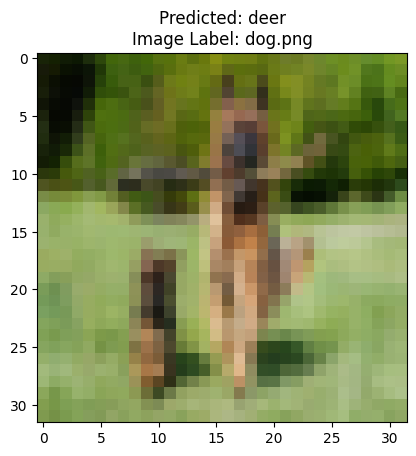

In [25]:
predict_images_in_folder(model, folder_path, classes, device)